# How to do Pair trading


Before pair trading, you need to
1. Understand the definition and the properties of cointegration.
2. Simulate cointegrated time series with python
3. Optimize the minimum total profit of a mean-reversion trading strategy on conintegrated asset pairs with python

   
# Cointegration
Pairs trading is defined as a trading strategy that involves matching a long position with a short position in two stocks with a high correlation. But, correlation of what?

Think about stock prices that have exactly 100% correlation in their returns. According to the definition of "high correlation," this could theoretically be used in pairs trading. However, it actually shouldn't be.

The reason is that when two stocks have a perfect 100% correlation in their returns, their prices move together in lockstep. This means that the price spread between the two stocks doesn't fluctuate, which is crucial for pairs trading. Pairs trading relies on the spread between the two stocks diverging and then converging. If there's no movement in the spread because the prices are perfectly correlated, there's no opportunity to profit from the trade.

So, while high correlation is important, it's not just about any correlation. It's specifically about finding pairs where the correlation allows for meaningful divergence and convergence in the price spread, which is where the trading opportunity lies.



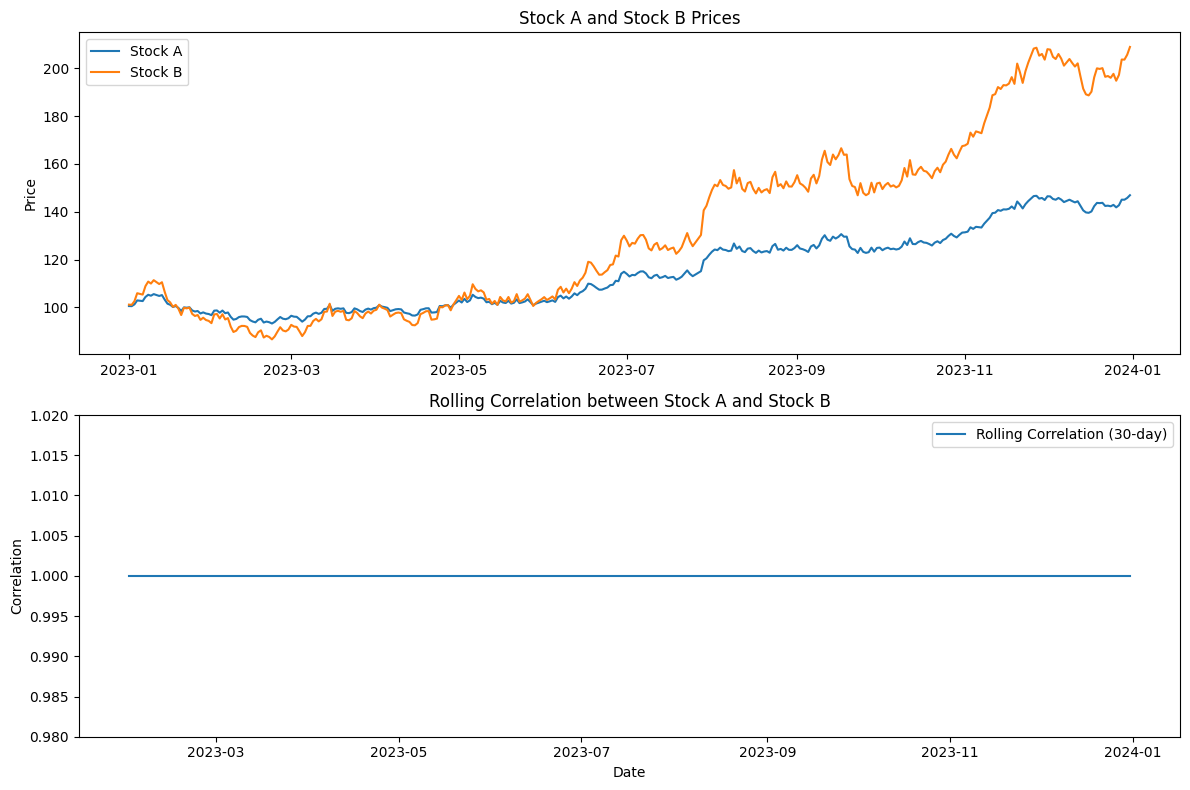

In [21]:
np.random.seed(42)  # For reproducibility
stock_a_returns = pd.Series(np.random.normal(0.001, 0.01, len(dates)), index=dates)
stock_b_returns = 2 * stock_a_returns

stock_a_prices = 100* (1+stock_a_returns).cumprod()
stock_b_prices = 100 * (1 + stock_b_returns).cumprod()

data = pd.DataFrame({
    'Date': dates,
    'Stock_A': stock_a_prices,
    'Stock_B': stock_b_prices
}).set_index('Date')


import matplotlib.pyplot as plt

rolling_corr = data['Stock_A'].pct_change().rolling(window=30).corr(data['Stock_B'].pct_change())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(data['Stock_A'], label='Stock A')
ax1.plot(data['Stock_B'], label='Stock B')
ax1.set_title('Stock A and Stock B Prices')
ax1.set_ylabel('Price')
ax1.legend()

ax2.plot(rolling_corr, label='Rolling Correlation (30-day)')
ax2.set_title('Rolling Correlation between Stock A and Stock B')
ax2.set_ylabel('Correlation')
ax2.set_ylim(0.98, 1.02)  # Setting limits close to 1 to highlight the perfect correlation
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.show()



As you can see here, even if the correlation is 100%—which might seem perfect for pairs trading—this situation actually cannot be used in pairs trading. The reason is the infinite divergence of the price series. When two stock prices are perfectly correlated in this way, their price movements are locked together, and they will never meet or converge again in the future. This eliminates any opportunity to profit from the convergence of their prices, which is the core idea behind pairs trading.

In contrast, consider a different case like Nasdaq and Apple stock prices. Although they may have a high correlation, their price series are not perfectly locked together. They have the potential to diverge and then converge, which creates an opportunity for pairs trading. Here, the spread between their prices can widen and then narrow again, allowing traders to capitalize on the eventual reversion to the mean or historical relationship.


[*********************100%%**********************]  2 of 2 completed


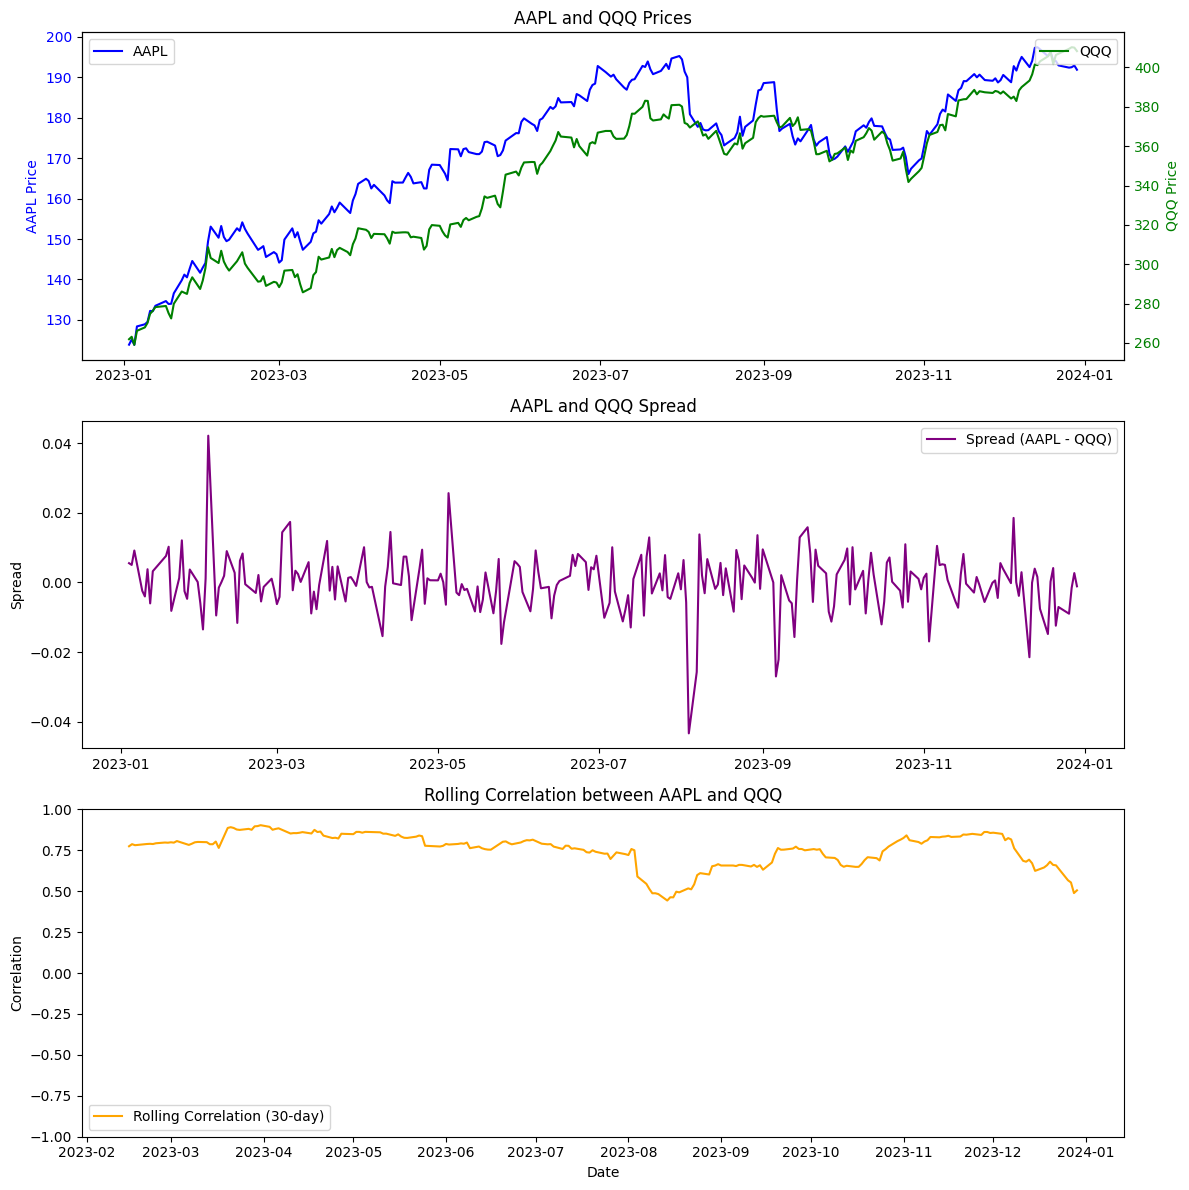

In [24]:
import yfinance as yf
import matplotlib.pyplot as plt

tickers = ['AAPL', 'QQQ']
data = yf.download(tickers, start="2023-01-01", end="2024-01-01")['Adj Close']

returns = data.pct_change().dropna()

returns['Spread'] = returns['AAPL'] - returns['QQQ']

rolling_corr = returns['AAPL'].rolling(window=30).corr(returns['QQQ'])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

ax1.plot(data.index, data['AAPL'], label='AAPL', color='blue')
ax1.set_ylabel('AAPL Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax1_twin = ax1.twinx()
ax1_twin.plot(data.index, data['QQQ'], label='QQQ', color='green')
ax1_twin.set_ylabel('QQQ Price', color='green')
ax1_twin.tick_params(axis='y', labelcolor='green')

ax1.set_title('AAPL and QQQ Prices')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

ax2.plot(returns.index, returns['Spread'], label='Spread (AAPL - QQQ)', color='purple')
ax2.set_title('AAPL and QQQ Spread')
ax2.set_ylabel('Spread')
ax2.legend()

ax3.plot(rolling_corr, label='Rolling Correlation (30-day)', color='orange')
ax3.set_title('Rolling Correlation between AAPL and QQQ')
ax3.set_ylabel('Correlation')
ax3.set_ylim(-1, 1)  # Set limits from -1 to 1 to show the full range of correlation
ax3.set_xlabel('Date')
ax3.legend()

plt.tight_layout()
plt.show()



# Pairs Trading : Conintegration

So, we calculate the correlation between returns. then what would be a good way to describe the relationship between asset prices?
The answer is Conintegration.

Cointegration : I(d) series
- I(d) series means "integrated series of order d"
- I(1) series :
      price
      Yield
      Exchange rate
- I(0) series:
      returns
I(0) series can be obtained by differencing an I(1) series.

I(0) series is weak-sense stationary.
    Mean function is finite and time-invariant
    Variance function is finite and time-invariant
    Covariance function depends only on time lag
The time-invariant mean of I(0) series is the basis of a mean-reversion trading strategy.

$x_t$ and $y_t$ are conintegrated, if $x_t$ and $y_t$ are I(1) series and $\exists \beta \text{ such that } z_t = x_t - \beta y_t \text{ is an } I(0) \text{ series.}$



# Cointegration : Properties

- The prices of cointegrated assets are tethered due to the stationarity of their spread.<br>
- Cointegration is a measure of similarity of assets in terms of risk exposure profiles.<br>
- Cointegration describes a long-term relationship between asset prices; correlation is a short-term relationship between returns.<br>
- Cointegration specifies the ratio of the long leg to the short leg, $\beta$ <br>
- How to find $\beta$?<br>
      Engle-Granger test (Suitable for a pair of assets) <br>
          - Linear regression on asset prices and test if the residual is stationary.<br>
          - Drawback : Which asset to choose as the dependent variable?<br>
      Johansen test (Suitable for two or more assets)<br>
          - Vector Error Correction Model (VECM)<br>
          - Preferred method to test for cointegration and derive $\beta$.<br>

# Simulating Cointegrated Pairs

How to figure out cointegrated pairs?

- if as time series is stationary, then it must be an I(0) series.
- Simulate I(0) series with stationary AR(1) process

$$
a_t = \varphi a_{t-1} + \epsilon_t, \quad |\varphi| < 1 
$$ <br>

Where 
$$
\epsilon_t \sim N(0, \sigma^2).
$$

Two components are I(0) series
    - Returns of one asset
    - Spread of the cointegrated pairs <br>

The process of simulation would be
1. Simulate the log price of asset Y, $y_t$, such that $y_t - y_{t-1} = a_t + c_1$, where $a_t$ is stationary AR(1).
2. Sum up $a_t$ and obtain the log price of asset Y.
3. Simulate the cointegrated spread between asset X and asset Y, such that $x_t + \beta y_t = b_t + c_2$, where $b_t$ is stationary AR(1).
4. Retrieve the log price of asset X, $x_t$, by calculating $x_t = b_t - \beta y_t$




[*********************100%%**********************]  2 of 2 completed


C:\Users\Miraisucrypt\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Miraisucrypt\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Miraisucrypt\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Miraisucrypt\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it ha

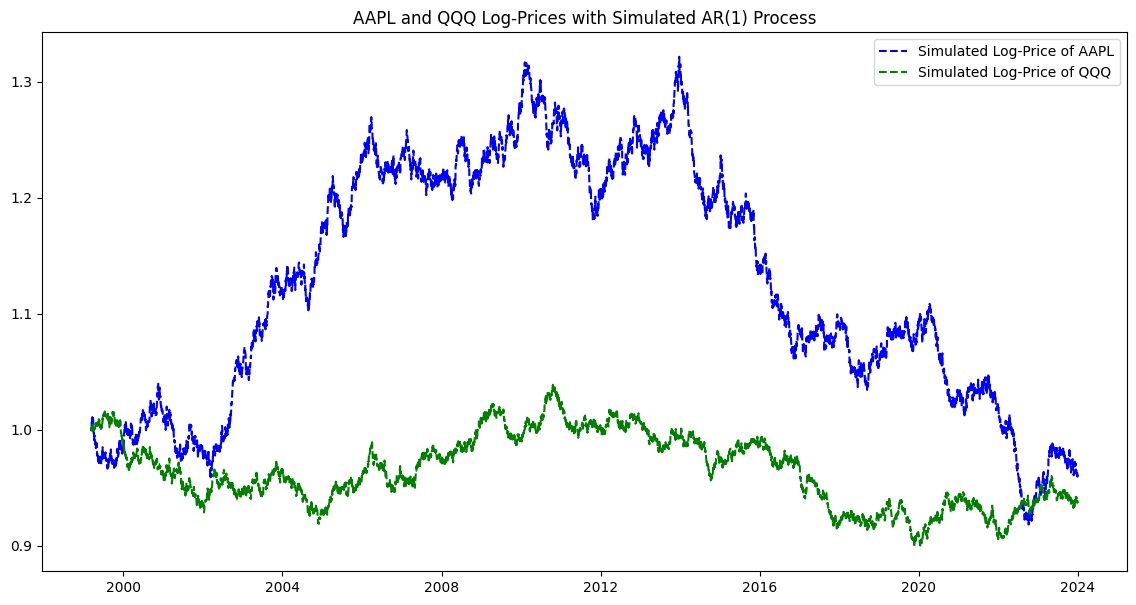

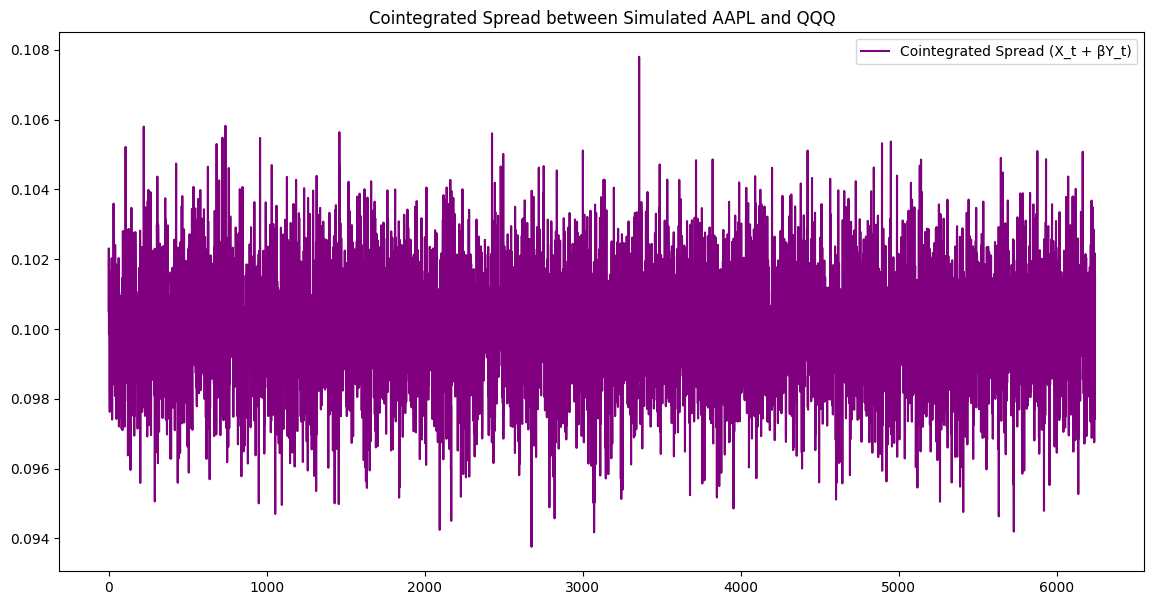

In [67]:
import yfinance as yf
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

tickers = ['AAPL', 'QQQ']
data = yf.download(tickers, start="1980-01-01", end="2024-01-01")['Adj Close']

log_prices = np.log(data)
log_returns = log_prices.diff().dropna()

model_aapl = sm.tsa.ARIMA(log_returns['AAPL'], order=(1, 0, 0)).fit()
model_qqq = sm.tsa.ARIMA(log_returns['QQQ'], order=(1, 0, 0)).fit()

phi_aapl = min(model_aapl.params[1], 0.95)
phi_qqq = min(model_qqq.params[1], 0.95)
sigma_a = np.std(log_returns['AAPL'])
sigma_b = np.std(log_returns['QQQ'])

np.random.seed(42)
n = len(log_returns)

eps_aapl = np.random.normal(0, np.std(log_returns['AAPL']) * 0.1, n)  # Reduced noise
aapl_sim = np.zeros(n)
aapl_sim[0] = log_returns['AAPL'].mean()
for t in range(1, n):
    aapl_sim[t] = phi_aapl * aapl_sim[t-1] + eps_aapl[t] #I've removed the drift term for simplification

eps_qqq = np.random.normal(0, np.std(log_returns['QQQ']) * 0.1, n)  # Reduced noise
qqq_sim = np.zeros(n)
qqq_sim[0] = log_returns['QQQ'].mean()
for t in range(1, n):
    qqq_sim[t] = phi_qqq * qqq_sim[t-1] + eps_qqq[t]

aapl_sim_prices = pd.Series(np.exp(np.cumsum(aapl_sim)), index=log_returns.index)
qqq_sim_prices = pd.Series(np.exp(np.cumsum(qqq_sim)), index=log_returns.index)

plt.figure(figsize=(14, 7))
plt.plot(aapl_sim_prices, label='Simulated Log Price of AAPL', linestyle='--', color='blue')
plt.plot(qqq_sim_prices, label='Simulated Log Price of QQQ', linestyle='--', color='green')
plt.title('AAPL and QQQ Log Prices with Simulated AR(1) Process')
plt.legend()
plt.show()

beta = 1.2  # Cointegration coefficient
eps_b = np.random.normal(0, np.std(log_returns['QQQ']) * 0.1, n)  # Reduced noise
b_t = np.zeros(n)
b_t[0] = eps_b[0]
for t in range(1, n):
    b_t[t] = phi_qqq * b_t[t-1] + eps_b[t]

x_t_log_price = b_t - beta * qqq_sim + c2
x_t_price = pd.Series(np.exp(np.cumsum(x_t_log_price)), index=log_returns.index)

spread = x_t_log_price + beta * qqq_sim
plt.figure(figsize=(14, 7))
plt.plot(spread, label='Cointegrated Spread (X_t + βY_t)', color='purple')
plt.title('Cointegrated Spread between Simulated AAPL and QQQ')
plt.legend()
plt.show()


# Optimizing Trading strategy

- The spread between the cointegrated assets is mean-reverting.
- The trading strategy is intuitive:fade the extreames

Questions are: <br>
1. Where to initiate the trades?
2. How frequent are the trades?

Optimization Target: <br>
    Trade Location * Trade Frequency

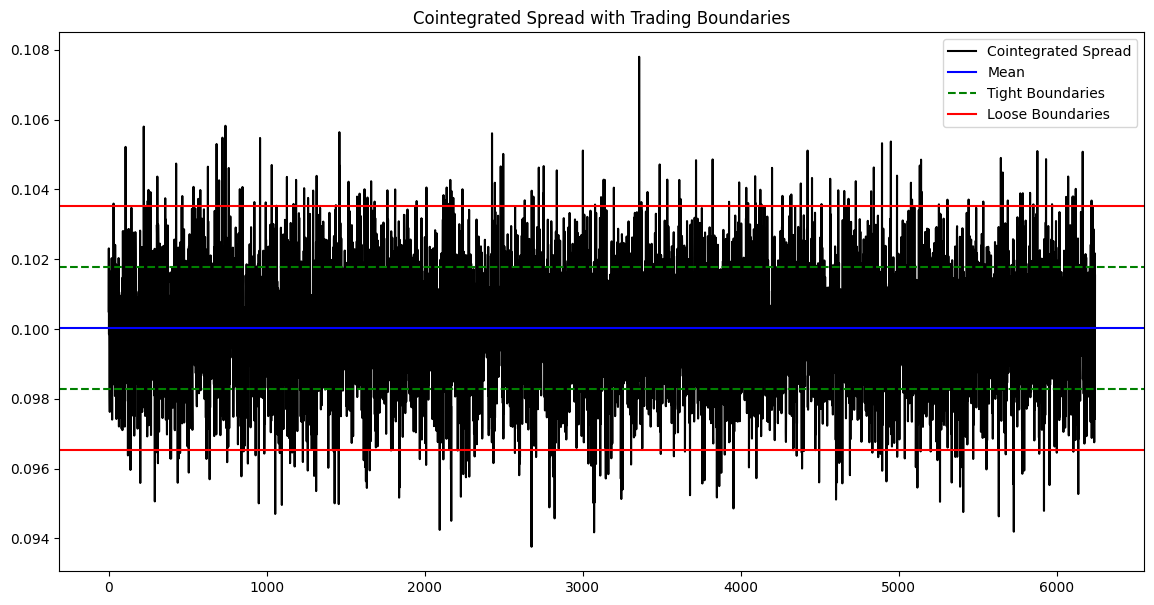

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mean_spread = np.mean(spread)
std_spread = np.std(spread)

upper_bound_tight = mean_spread + std_spread
lower_bound_tight = mean_spread - std_spread

upper_bound_loose = mean_spread + 2 * std_spread
lower_bound_loose = mean_spread - 2 * std_spread

plt.figure(figsize=(14, 7))
plt.plot(spread, label='Cointegrated Spread', color='black')

plt.axhline(mean_spread, color='blue', linestyle='-', label='Mean')
plt.axhline(upper_bound_tight, color='green', linestyle='--', label='Tight Boundaries')
plt.axhline(lower_bound_tight, color='green', linestyle='--')

plt.axhline(upper_bound_loose, color='red', linestyle='-', label='Loose Boundaries')
plt.axhline(lower_bound_loose, color='red', linestyle='-')

plt.title('Cointegrated Spread with Trading Boundaries')
plt.legend()
plt.show()


Tighter boundaries, smaller minimum profit per trade, higher trade frequency, <br>
Looser boundaries, larget minimum profit per trade, lower trade frequency.


## Trade Location: Minimum Profit Per Trade

### Trading Strategy

- If $ \epsilon_t \geq U $, sell $ N $ of asset $ X $, buy $ \beta N $ of asset $ Y $
- If $ \epsilon_t \leq E[\epsilon_t] $, close the trade

- If $ \epsilon_t \leq U $, buy $ N $ of asset $ X $, sell $ \beta N $ of asset $ Y $
- If $ \epsilon_t \geq E[\epsilon_t] $, close the trade

### Profit per Trade

$$
P = N \left( X_o - X_c \right) + \beta N \left( Y_c - Y_o \right)
$$

$$
P = N \left( X_o - \beta Y_o \right) - N \left( X_c - \beta Y_c \right)
$$

$$
P = N \epsilon_{t_o} - N \epsilon_{t_c} \geq N U
$$

The minimum profit per trade, when trading 1 unit of the spread, is exactly the boundary value U.


# Trade Frequency : Mean First-passage Time

- Assume the cointegrated spread, $\epsilon_t$, between asset X, and asset Y is a stationary AR(1) process.

- Use mean first-passage time of the AR(1) process to optimize the trade duration and inter-trade interval. <br>
    Trade duration : the mean first-passage time of $\epsilon_t$ to pass the mean $E[\epsilon_t]$, if the starting point is at U. <br>
    Inter-trade interval : the mean first-passage time of $\epsilon_t$ to pass U, if the starting point is at the mean $E[\epsilon_t]$.
    Zero the mean for easier calculation.

## Trade duration
$$
E \left( T_{0, \infty}(U) \right) = \lim_{b \to \infty} \int_{0}^{b} E \left( T_{0, b}(s) \right) \exp \left( - \frac{(s - \phi U)^2}{2 \sigma_a^2} \right) ds + 1
$$

## Inter-trade Interval
$$
E \left( T_{-\infty, U}(0) \right) = \lim_{-b \to -\infty} \int_{-b}^{U} E \left( T_{-b, U}(s) \right) \exp \left( - \frac{s^2}{2 \sigma_a^2} \right) ds + 1
$$


Expected Trade Duration (E(T_{0, ∞}(U))): 1.032634545695348
Expected Inter-Trade Interval (E(T_{-∞, U}(0))): 1.034457248845793


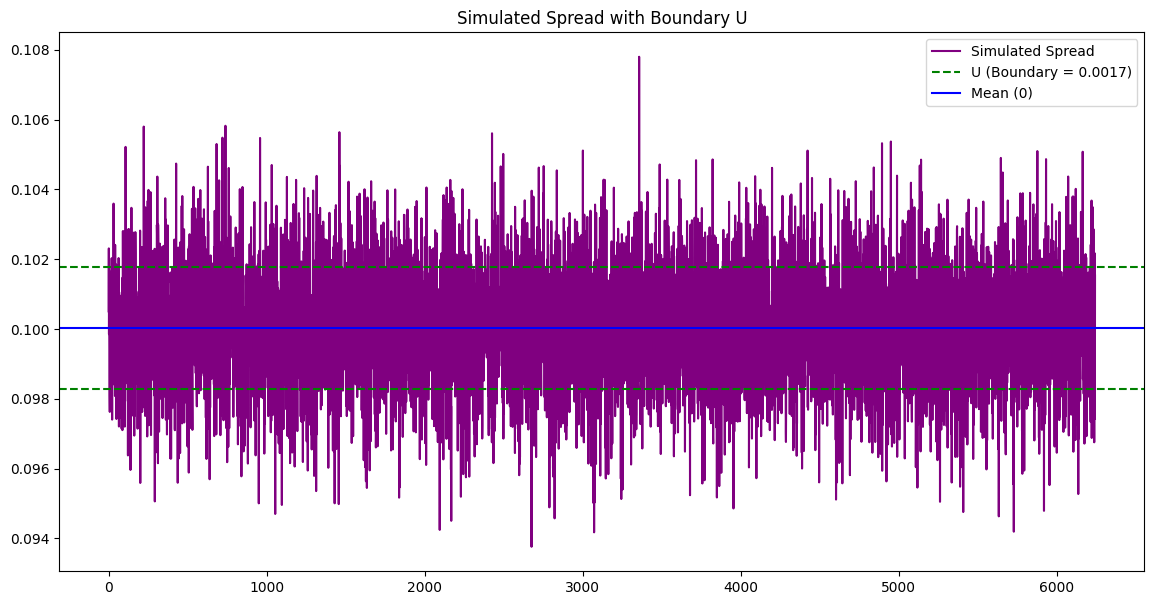

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



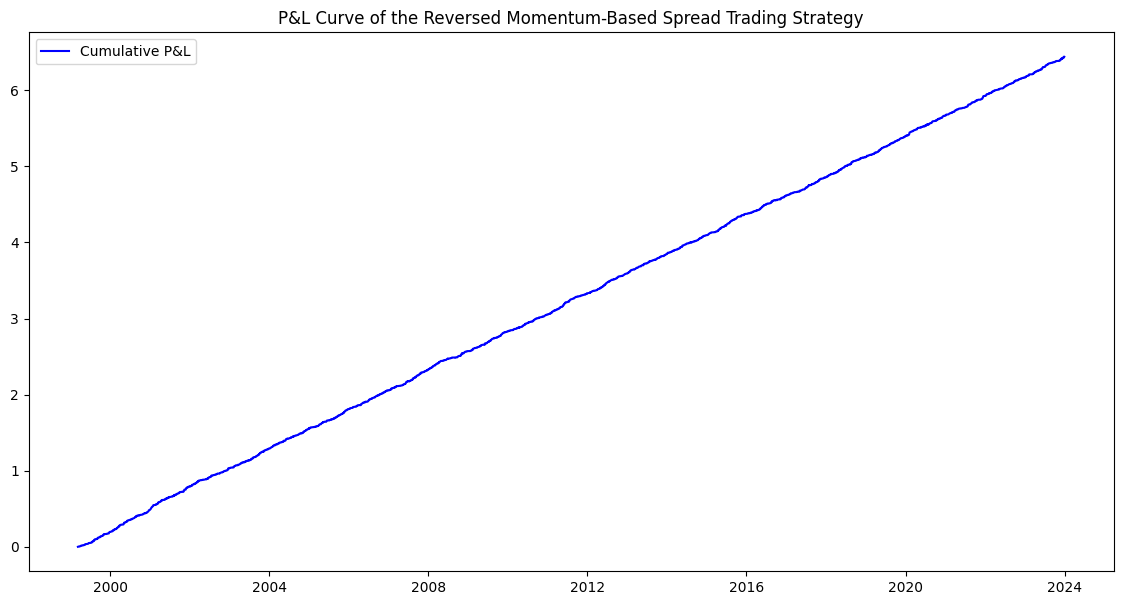

In [66]:
from scipy.integrate import quad
mean_spread = np.mean(spread)
U = np.std(spread)  # Boundary
sigma = sigma_a  # Assume the noise is the same for simplicity

def integrand_trade_duration(s, U, phi, sigma):
    return np.exp(-((s - phi * U)**2) / (2 * sigma**2))

def E_T_0_inf(U, phi, sigma):
    integral_value, _ = quad(lambda s: integrand_trade_duration(s, U, phi, sigma), 0, np.inf)
    return integral_value + 1

trade_duration_mfpt = E_T_0_inf(U, phi_aapl, sigma)

def integrand_inter_trade_interval(s, sigma):
    return np.exp(-(s**2) / (2 * sigma**2))

def E_T_inf_U(U, sigma):
    integral_value, _ = quad(lambda s: integrand_inter_trade_interval(s, sigma), -np.inf, U)
    return integral_value + 1

inter_trade_interval_mfpt = E_T_inf_U(U, sigma)

#the optimized metrics
print(f"Expected Trade Duration (E(T_{{0, ∞}}(U))): {trade_duration_mfpt}")
print(f"Expected Inter-Trade Interval (E(T_{{-∞, U}}(0))): {inter_trade_interval_mfpt}")


plt.figure(figsize=(14, 7))
plt.plot(spread, label='Simulated Spread', color='purple')
plt.axhline(mean_spread+U, color='green', linestyle='--', label=f'U (Boundary = {U:.4f})')
plt.axhline(mean_spread-U, color='green', linestyle='--')
plt.axhline(mean_spread, color='blue', linestyle='-', label='Mean (0)')
plt.title('Simulated Spread with Boundary U')
plt.legend()
plt.show()

signals = pd.DataFrame(index=log_returns.index)
signals['spread'] = spread
signals['signal'] = 0

signals['signal'][spread < mean_spread - U] = 1  # Buy signal when spread is below mean - U
signals['signal'][spread > mean_spread + U] = -1  # Sell signal when spread is above mean + U
signals['positions'] = 0

for i in range(1, len(signals)):
    if signals['signal'][i] == 1:  # Opening a long position
        signals['positions'][i] = 1
    elif signals['signal'][i] == -1:  # Opening a short position
        signals['positions'][i] = -1
    elif signals['positions'][i-1] == 1 and spread[i] >= mean_spread:  # Close long position
        signals['positions'][i] = 0
    elif signals['positions'][i-1] == -1 and spread[i] <= mean_spread:  # Close short position
        signals['positions'][i] = 0
    else:  # Carry forward the previous position
        signals['positions'][i] = signals['positions'][i-1]

pnl = signals['positions'].shift(1) * signals['spread'].diff().fillna(0)
pnl_cumulative = pnl.cumsum()

#pnl Curve
plt.figure(figsize=(14, 7))
plt.plot(pnl_cumulative, label='Cumulative P&L', color='blue')
plt.title('P&L Curve of the Reversed Momentum-Based Spread Trading Strategy')
plt.legend()
plt.show()